In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
# Loading data
iris = datasets.load_iris ()

In [38]:
X, y = iris . data[:,: 2 ], iris . target
# We keep 50% of the dataset for evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.5 )



In [39]:
C = 1.0 # regularization parameter
lin_svc = svm . LinearSVC(C = C)
lin_svc . fit(X_train, y_train)

LinearSVC()

In [40]:
from sklearn.metrics import accuracy_score

y_pred=lin_svc.predict(X_test)

accuracy=accuracy_score(y_pred,y_test)

accuracy

0.6533333333333333

In [41]:
X, y = iris . data, iris . target
# We keep 50% of the dataset for evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.5 )



In [42]:
C = 1.0 # regularization parameter
lin_svc = svm . LinearSVC(C = C)
lin_svc . fit(X_train, y_train)

LinearSVC()

In [43]:
from sklearn.metrics import accuracy_score

y_pred=lin_svc.predict(X_test)

accuracy=accuracy_score(y_pred,y_test)

accuracy

0.96

the accuracy increased by 20%, because the data became more seperable when we introduced more dimensions.

LIBLINEAR handles multiclass classification primarily using the one-versus-the-rest (OvR) strategy.
For each class i, a binary SVM model is trained to distinguish that specific class from all the other classes combined (the "rest"). This results in a set of k models.
To classify a new data instance, each of the k classifiers produces a decision value (or score). The final predicted class is the one corresponding to the classifier that yields the highest decision value.

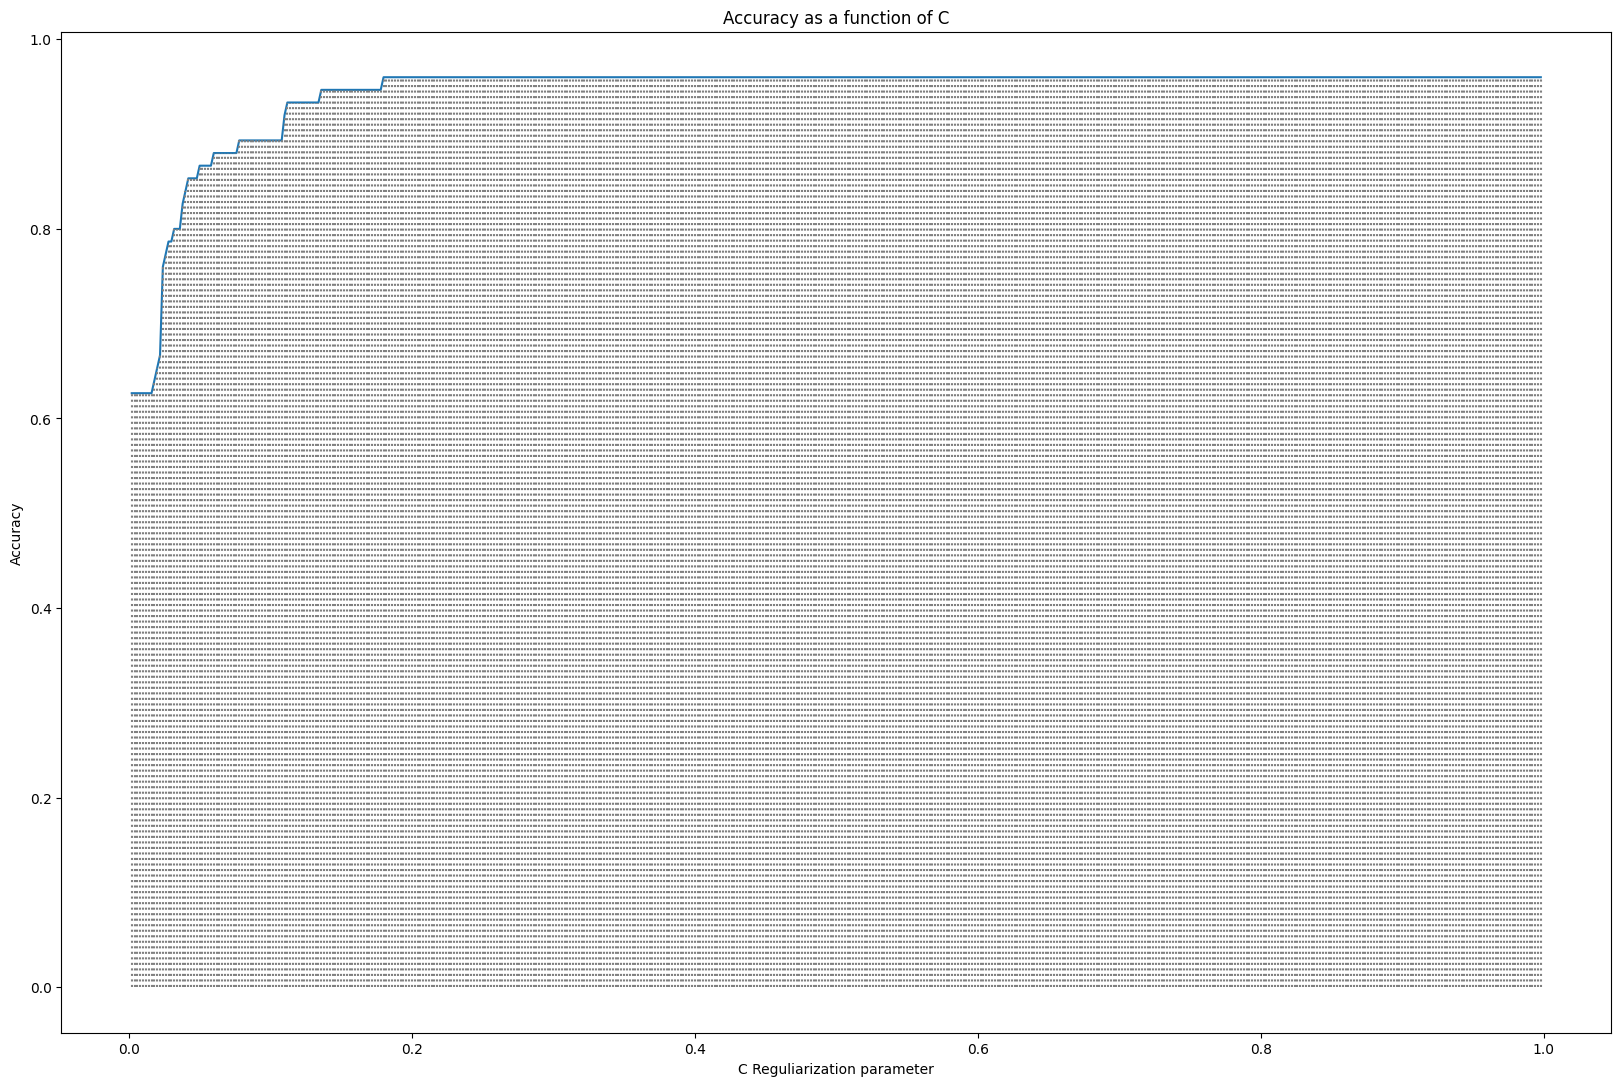

0.96 0.18


In [44]:
Cs=np.arange(0.002,1,0.002)
accuracies=[]
optimal_c=0
optimal_accuracy=0
for C in Cs:
    lin_svc = svm . LinearSVC(C = C)
    lin_svc . fit(X_train, y_train)
    y_pred=lin_svc.predict(X_test)
    accuracy=accuracy_score(y_pred,y_test)
    accuracies.append(accuracy)
    if accuracy>optimal_accuracy:
        optimal_accuracy=accuracy
        optimal_c=C

    
plt.figure(figsize =(20,13))
plt.plot(Cs, accuracies)

plt.vlines(Cs,0, accuracies, linestyle="dotted", color="gray")
plt.xlabel("C Reguliarization parameter")
plt.ylabel("Accuracy")
plt.title("Accuracy as a function of C")
plt.show()

print(optimal_accuracy, optimal_c)


the best C is .18 and it gives an accuracy of 96%

In [45]:
from sklearn.model_selection import GridSearchCV

param_grid = [
  {'C': np.arange(0.2,2,0.2), 'gamma': np.arange(0.0001,0.005,0.0001), 'kernel': ['rbf']},
]

svc = svm.SVC()
# Initialize GridSearchCV
grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1,)

# Fit the GridSearchCV object to the data
grid_search.fit(X_train, y_train)

# Print the best parameters found
print(f"Best parameters: {grid_search.best_params_}")

# Print the best cross-validation score
print(f"Best score (accuracy): {grid_search.best_score_}")

# Get the best estimator (the optimized SVM model)
best_svm_model = grid_search.best_estimator_


Best parameters: {'C': 1.8, 'gamma': 0.004300000000000001, 'kernel': 'rbf'}
Best score (accuracy): 0.96


Exception ignored in: <function ResourceTracker.__del__ at 0x7f8fde6163e0>
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7fcba80c63e0>
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f830cb123e0>
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multip